# Trabajo práctico 1: Optimización

> Notebook canónico y autocontenido del proyecto.

**Equipo:** Alejandro Quesada, Manfred Azofeifa, Jose Adrián Herrera

**Estado:** trabajo en progreso; análisis gráfico inicial implementado.


## Objetivo y protocolo

- TODO: Resumir el objetivo del experimento.
- TODO: Definir criterios de convergencia y métricas.
- TODO: Registrar decisiones que deban mantenerse entre algoritmos.


## Configuración y reproducibilidad

Esta sección debe concentrar imports, semilla, dispositivo, dominio, número de corridas, puntos iniciales compartidos y demás parámetros globales.


In [1]:
# TODO: Agregar imports y definir aquí toda la configuración compartida.
# TODO: Crear una sola vez los puntos iniciales reutilizados por los algoritmos.
import math
import warnings

import torch
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
from IPython.display import display


DOMAIN_MIN = -10.0
DOMAIN_MAX = 10.0
GRID_POINTS = 401
# Permite ejecutar el notebook desde la raíz del repositorio o desde notebooks/.
try:
    from utils import plot_critical_points
except (ModuleNotFoundError, ImportError):
    from notebooks.utils import plot_critical_points

## Convención de documentación interna

Documentar cada función con bloques compatibles con Doxygen. Ejemplo genérico:

```python
def metodo(entrada):
    """!
    @brief Descripción breve.
    @param entrada Descripción del parámetro.
    @return Descripción del resultado.
    """
```


### Función auxiliar para graficación de funciones en 2D


In [2]:
def plot_function_2d_3d(x_grid, y_grid, values, title, z_label):
    """!
    @brief Grafica curvas de nivel y una superficie 3D para una función muestreada.
    @param x_grid Malla con las coordenadas x.
    @param y_grid Malla con las coordenadas y.
    @param values Valores de la función sobre la malla.
    @param title Título descriptivo de la figura.
    @param z_label Etiqueta del valor de la función.
    """
    x_values = x_grid.numpy()
    y_values = y_grid.numpy()
    z_values = values.numpy()

    fig = plt.figure(figsize=(14, 5), constrained_layout=True)
    fig.suptitle(title, fontsize=14)

    contour_axis = fig.add_subplot(1, 2, 1)
    contours = contour_axis.contourf(
        x_values, y_values, z_values, levels=50, cmap="viridis"
    )
    contour_axis.set(
        xlabel="x", ylabel="y", title="Curvas de nivel",
        xlim=(DOMAIN_MIN, DOMAIN_MAX), ylim=(DOMAIN_MIN, DOMAIN_MAX),
    )
    contour_axis.set_aspect("equal", adjustable="box")
    contour_colorbar = fig.colorbar(contours, ax=contour_axis)
    contour_colorbar.set_label(z_label)

    surface_axis = fig.add_subplot(1, 2, 2, projection="3d")
    surface = surface_axis.plot_surface(
        x_values,
        y_values,
        z_values,
        cmap="viridis",
        rstride=2,
        cstride=2,
        linewidth=0,
        antialiased=True,
    )
    surface_axis.set(
        xlabel="x", ylabel="y", zlabel=z_label, title="Superficie 3D",
        xlim=(DOMAIN_MIN, DOMAIN_MAX), ylim=(DOMAIN_MIN, DOMAIN_MAX),
    )
    surface_axis.view_init(elev=28, azim=-55)
    surface_axis.set_box_aspect((1, 1, 0.65))
    surface_colorbar = fig.colorbar(surface, ax=surface_axis, shrink=0.72, pad=0.10)
    surface_colorbar.set_label(z_label)

    plt.show()


## Análisis de las funciones

Las tres funciones se evalúan sobre una malla compartida en $[-10, 10]^2$ y se muestran mediante curvas de nivel y superficies 3D.

### 1) $f_0(x, y)$  - Función Cuadrática
$$
f_0(x, y) = x^2 + y^2
$$


In [3]:
def f0(x, y):
    """!
    @brief Evalúa la función cuadrática f0 sobre tensores de PyTorch.
    @param x Coordenadas x.
    @param y Coordenadas y.
    @return Valores de f0(x, y).
    """
    return x ** 2 + y ** 2

x = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)
y = torch.linspace(DOMAIN_MIN, DOMAIN_MAX, GRID_POINTS)

X, Y = torch.meshgrid(x, y, indexing='ij')
Z0 = f0(X, Y)
Z0.shape

torch.Size([401, 401])

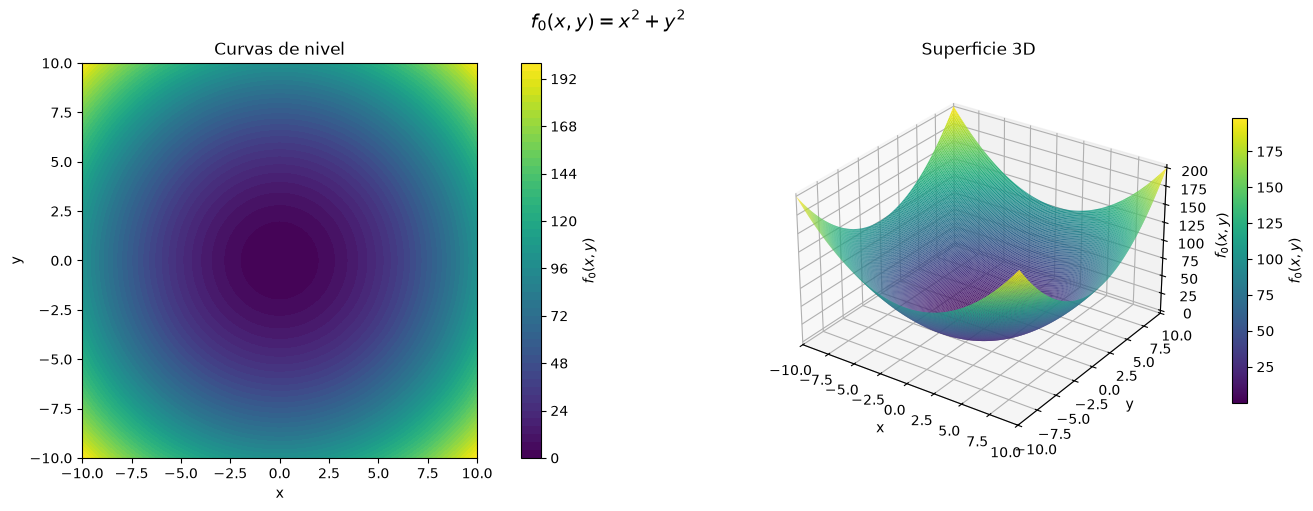

In [4]:
plot_function_2d_3d(X, Y, Z0,
    title=r"$f_0(x, y) = x^2 + y^2$",
    z_label=r"$f_0(x, y)$",
)

### $f_1(x, y)$ - función de Ackley

$$f_1(x,y) = -20\exp\left(-0.2\sqrt{0.5(x^2+y^2)}\right) - \exp\left(0.5(\cos(2\pi x)+\cos(2\pi y))\right) + e + 20$$


In [5]:
def f1(x, y):
    """!
    @brief Evalúa la función de Ackley f1 sobre tensores de PyTorch.
    @param x Coordenadas x.
    @param y Coordenadas y.
    @return Valores de f1(x, y).
    """
    radio = torch.linalg.vector_norm(torch.stack((x, y)), dim=0)
    term1 = -20.0 * torch.exp(-0.2 * radio / math.sqrt(2.0))
    term2 = -torch.exp(0.5 * (torch.cos(2.0 * math.pi * x) + torch.cos(2.0 * math.pi * y)))
    return term1 + term2 + math.e + 20.0

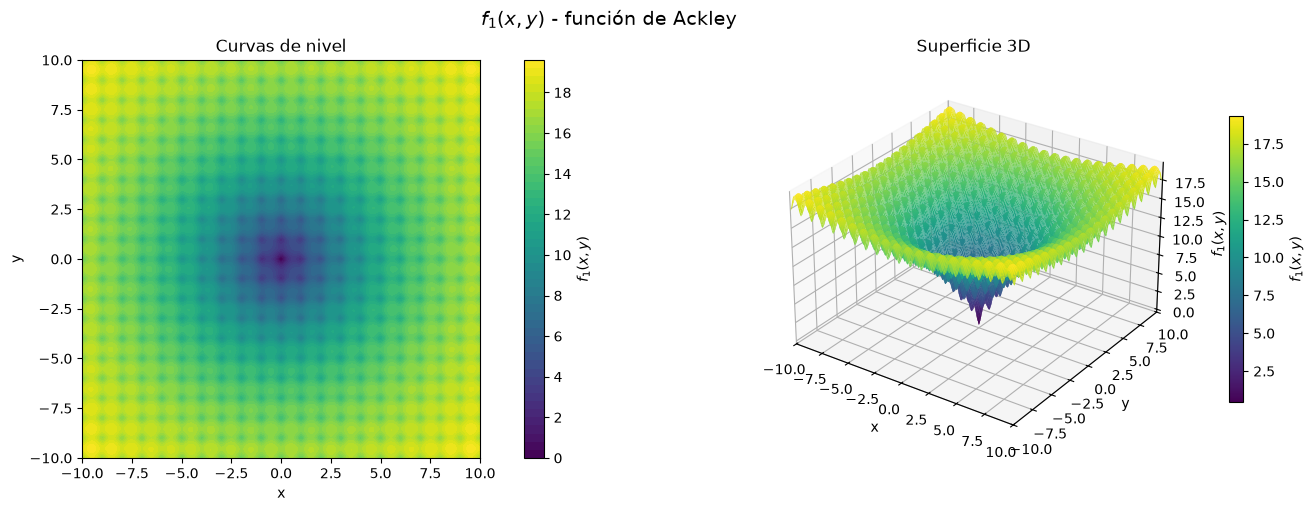

In [6]:
Z1 = f1(X, Y)
plot_function_2d_3d(X, Y, Z1,
    title=r"$f_1(x, y)$ - función de Ackley",
    z_label=r"$f_1(x, y)$",
)

### $f_2(x, y)$ - función de Himmelblau

$$f_2(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$$


In [7]:
def f2(x, y):
    """!
    @brief Evalúa la función de Himmelblau f2 sobre tensores de PyTorch.
    @param x Coordenadas x.
    @param y Coordenadas y.
    @return Valores de f2(x, y).
    """
    return (x ** 2 + y - 11.0) ** 2 + (x + y ** 2 - 7.0) ** 2

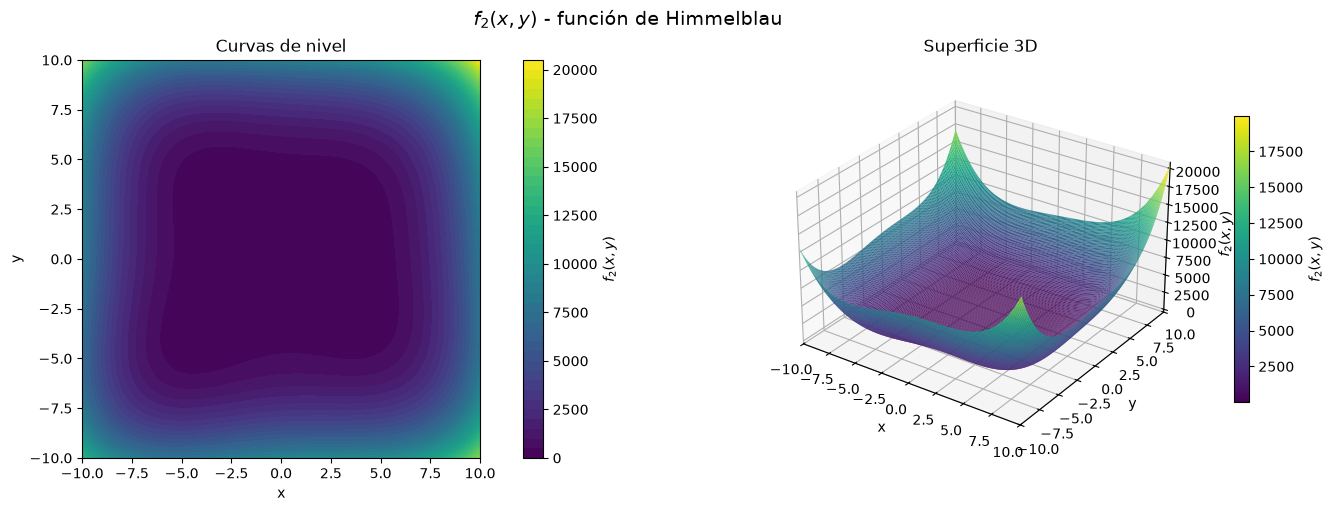

In [8]:
Z2 = f2(X, Y)
plot_function_2d_3d(X, Y, Z2,
    title=r"$f_2(x, y)$ - función de Himmelblau",
    z_label=r"$f_2(x, y)$",
)

---
### ¿Son convexas o no convexas?

- $f_0$ es convexa.
- $f_1$ y $f_2$ son no convexas.

---
### Encontrando mínimos y puntos silla con PyTorch

Primero usamos la malla que ya construimos. `torch.min(Z)` devuelve el menor **valor muestreado**, mientras que `torch.argmin(Z)` permite recuperar sus coordenadas. Como la malla contiene una cantidad finita de puntos, este resultado es una aproximación cuya precisión depende de `GRID_POINTS`.

Después usamos Autograd para buscar puntos donde el gradiente sea cercano a cero. Esos puntos se clasifican como mínimos locales o puntos silla con una prueba sencilla sobre la Hessiana $2\times2$.

In [9]:
# Valores mínimos aproximados observados en la malla
min0 = torch.min(Z0)
min1 = torch.min(Z1)
min2 = torch.min(Z2)


def coordenadas_minimo_malla(x_grid, y_grid, values):
    """!
    @brief Obtiene las coordenadas del menor valor guardado en una malla.
    @param x_grid Malla con las coordenadas x.
    @param y_grid Malla con las coordenadas y.
    @param values Valores de la función sobre la malla.
    @return Tensor con las coordenadas aproximadas del mínimo.
    """
    flat_index = torch.argmin(values)
    row = flat_index // values.shape[1]
    column = flat_index % values.shape[1]
    return torch.stack((x_grid[row, column], y_grid[row, column]))


puntos_minimos_malla = {
    "f0": coordenadas_minimo_malla(X, Y, Z0),
    "f1": coordenadas_minimo_malla(X, Y, Z1),
    "f2": coordenadas_minimo_malla(X, Y, Z2),
}

resumen_malla = pd.DataFrame(
    [
        {
            "función": "f0",
            "x": puntos_minimos_malla["f0"][0].item(),
            "y": puntos_minimos_malla["f0"][1].item(),
            "valor mínimo en la malla": min0.item(),
        },
        {
            "función": "f1",
            "x": puntos_minimos_malla["f1"][0].item(),
            "y": puntos_minimos_malla["f1"][1].item(),
            "valor mínimo en la malla": min1.item(),
        },
        {
            "función": "f2",
            "x": puntos_minimos_malla["f2"][0].item(),
            "y": puntos_minimos_malla["f2"][1].item(),
            "valor mínimo en la malla": min2.item(),
        },
    ]
)
resumen_malla["valor mínimo en la malla"] = resumen_malla[
    "valor mínimo en la malla"
].map(lambda value: f"{value:.3e}")
display(resumen_malla.round({"x": 6, "y": 6}))

,función,x,y,valor mínimo en la malla
0,f0,-0.0,-0.0,4.441e-14
1,f1,-0.0,-0.0,0.000e+00
2,f2,3.0,2.0,2.274e-13


#### 1. Gradiente y Hessiana con Autograd

Un punto crítico suave cumple $\nabla f(x,y)\approx(0,0)$. Para calcularlo, el tensor `punto` usa `requires_grad=True`. Luego `torch.autograd.grad` obtiene primero las dos componentes del gradiente y después las dos filas de la Hessiana.

In [10]:
# calculo de puntos silla usando pyTorch
def gradiente_y_hessiana(funcion, punto):
    """!
    @brief Calcula valor, gradiente y Hessiana de una función en un punto.
    @param funcion Función de dos variables implementada con PyTorch.
    @param punto Tensor de dos componentes con requires_grad=True.
    @return Tupla con valor, gradiente y matriz Hessiana.
    """
    valor = funcion(punto[0], punto[1])
    gradiente = torch.autograd.grad(
        valor, punto, create_graph=True
    )[0]

    filas_hessiana = []
    for componente in gradiente:
        fila = torch.autograd.grad(
            componente, punto, retain_graph=True
        )[0]
        filas_hessiana.append(fila)

    hessiana = torch.stack(filas_hessiana)
    return valor, gradiente, hessiana

#### 2. Refinamiento con el método de Newton

Las curvas de nivel nos dan puntos iniciales aproximados. Desde cada uno aplicamos

$$H(p)\,\text{paso}=\nabla f(p), \qquad p_{nuevo}=p-\text{paso}.$$

`torch.linalg.solve` resuelve el pequeño sistema lineal sin calcular explícitamente $H^{-1}$. Newton puede converger a un mínimo, un máximo o un punto silla; la clasificación se realiza en el paso siguiente.

> Newton depende del punto inicial y puede fallar si la Hessiana no es invertible. En ese caso se debe probar otro inicio tomado de la gráfica.

In [11]:
def encontrar_punto_estacionario(
    funcion,
    inicio,
    max_iteraciones=20,
    tolerancia=1e-8,
):
    """!
    @brief Refina un punto inicial hasta que su gradiente sea cercano a cero.
    @param funcion Función de dos variables implementada con PyTorch.
    @param inicio Tupla con las coordenadas iniciales.
    @param max_iteraciones Máximo de pasos de Newton.
    @param tolerancia Norma máxima del gradiente para detener el método.
    @return Tensor con el punto estacionario aproximado.
    """
    punto = torch.tensor(
        inicio,
        dtype=torch.float64,
        requires_grad=True,
    )

    for _ in range(max_iteraciones):
        _, gradiente, hessiana = gradiente_y_hessiana(
            funcion, punto
        )

        if torch.linalg.vector_norm(gradiente) < tolerancia:
            break

        paso = torch.linalg.solve(hessiana, gradiente)
        # La actualización no debe formar parte del grafo de Autograd.
        with torch.no_grad():
            punto -= paso

    return punto.detach()

#### 3. Clasificación con la Hessiana

Para una Hessiana de dos variables calculamos $D=\det(H)$:

- $D<0$: existen direcciones con curvaturas de signos opuestos, por lo que es un **punto silla**;
- $D>0$ y $f_{xx}>0$: hay curvatura positiva en ambas direcciones, por lo que es un **mínimo local**;
- $D>0$ y $f_{xx}<0$: es un máximo local;
- $D\approx0$: esta prueba no permite concluir.

También guardamos $\lVert\nabla f\rVert$ para comprobar que Newton realmente llegó cerca de un punto estacionario.

In [12]:
def clasificar_punto(funcion, punto, tolerancia=1e-6):
    """!
    @brief Clasifica un punto mediante el gradiente y la Hessiana 2x2.
    @param funcion Función de dos variables implementada con PyTorch.
    @param punto Tensor con las coordenadas del candidato.
    @param tolerancia Tolerancia usada en las comparaciones numéricas.
    @return Diccionario con coordenadas, valor y comprobaciones.
    """
    punto_autograd = punto.clone().detach().requires_grad_(True)
    valor, gradiente, hessiana = gradiente_y_hessiana(
        funcion, punto_autograd
    )

    norma_gradiente = torch.linalg.vector_norm(gradiente).item()
    determinante = torch.det(hessiana).item()
    f_xx = hessiana[0, 0].item()

    if norma_gradiente > tolerancia:
        tipo = "no convergió"
    elif determinante < -tolerancia:
        tipo = "punto silla"
    elif determinante > tolerancia and f_xx > 0:
        tipo = "mínimo local"
    elif determinante > tolerancia and f_xx < 0:
        tipo = "máximo local"
    else:
        tipo = "prueba inconclusa"

    return {
        "punto": punto.detach(),
        "tipo": tipo,
        "x": punto[0].item(),
        "y": punto[1].item(),
        "valor": valor.item(),
        "norma_gradiente": norma_gradiente,
        "det_hessiana": determinante,
    }

In [13]:
def resultados_a_tabla(resultados):
    """!
    @brief Convierte resultados de puntos críticos en una tabla compacta.
    @param resultados Lista de diccionarios creados por clasificar_punto.
    @return DataFrame con los valores necesarios para verificar cada punto.
    """
    columnas = [
        "tipo",
        "x",
        "y",
        "valor",
        "norma_gradiente",
        "det_hessiana",
    ]
    filas = [
        {columna: resultado[columna] for columna in columnas}
        for resultado in resultados
    ]
    tabla = pd.DataFrame(filas)
    tabla["norma_gradiente"] = tabla["norma_gradiente"].map(
        lambda value: f"{value:.2e}"
    )
    return tabla.round(
        {
            "x": 6,
            "y": 6,
            "valor": 6,
            "det_hessiana": 6,
        }
    )

#### 4. Resultados para $f_0$

Como $f_0=x^2+y^2\geq0$, el punto con valor cero es global. Además, su Hessiana es positiva y constante, de manera que no existen puntos silla.

In [14]:
punto_f0 = encontrar_punto_estacionario(f0, inicio=(1.0, 1.0))
resultado_f0 = clasificar_punto(f0, punto_f0)
resultado_f0["tipo"] = "mínimo global"

resultados_f0 = [resultado_f0]
minimos_globales_f0 = [resultado_f0["punto"]]
minimos_locales_f0 = []
puntos_silla_f0 = []

display(resultados_a_tabla(resultados_f0))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,0.0,0.0,0.0,0.00e+00,4.0


#### 5. Resultados para $f_1$ (Ackley)

El mínimo de la malla está en el origen y vale cero. También sabemos que $f_1\geq0$ porque el término radial no puede ser menor que $-20$ y el término periódico no puede ser menor que $-e$; por tanto, $(0,0)$ es el mínimo global.

En el origen la norma euclídea produce una punta no suave, así que no aplicamos allí la prueba Hessiana. Para practicar el procedimiento mostramos mínimos locales y puntos silla **representativos cerca del origen**. Ackley repite este patrón y tiene muchos más en todo $[-10,10]^2$.

In [15]:
inicios_minimos_f1 = [
    (-1.0, 0.0),
    (1.0, 0.0),
    (0.0, -1.0),
    (0.0, 1.0),
    (-1.0, -1.0),
    (-1.0, 1.0),
    (1.0, -1.0),
    (1.0, 1.0),
]
inicios_silla_f1 = [
    (-0.7, 0.0),
    (0.7, 0.0),
    (0.0, -0.7),
    (0.0, 0.7),
]

resultados_f1 = []
for inicio in inicios_minimos_f1 + inicios_silla_f1:
    punto = encontrar_punto_estacionario(f1, inicio)
    resultados_f1.append(clasificar_punto(f1, punto))

minimos_globales_f1 = [
    torch.tensor((0.0, 0.0), dtype=torch.float64)
]
minimos_locales_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "mínimo local"
]
puntos_silla_f1 = [
    resultado["punto"]
    for resultado in resultados_f1
    if resultado["tipo"] == "punto silla"
]

display(resultados_a_tabla(resultados_f1))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo local,-0.952167,0.000000,2.579928,6.74e-09,2613.708044
1,mínimo local,0.952167,0.000000,2.579928,6.74e-09,2613.708044
2,mínimo local,0.000000,-0.952167,2.579928,6.74e-09,2613.708044
3,mínimo local,0.000000,0.952167,2.579928,6.74e-09,2613.708044
4,mínimo local,-0.968478,-0.968478,3.574452,5.13e-10,2623.098354
5,mínimo local,-0.968478,0.968478,3.574452,5.13e-10,2623.098354
6,mínimo local,0.968478,-0.968478,3.574452,5.13e-10,2623.098354
7,mínimo local,0.968478,0.968478,3.574452,5.13e-10,2623.098354
8,punto silla,-0.625781,0.000000,3.252469,8.11e-11,-601.475321
9,punto silla,0.625781,0.000000,3.252469,8.11e-11,-601.475321


#### 6. Resultados para $f_2$ (Himmelblau)

`torch.argmin` mostró un solo mínimo de la malla porque devuelve un único índice. Usamos como inicios puntos aproximados observados en los otros valles de las curvas de nivel. Los cuatro mínimos encontrados hacen que los dos cuadrados de $f_2$ sean prácticamente cero; como una suma de cuadrados nunca es negativa, los cuatro son mínimos globales.

In [16]:
inicios_minimos_f2 = [
    (3.0, 2.0),
    (-3.0, 3.0),
    (-4.0, -3.0),
    (4.0, -2.0),
]
inicios_silla_f2 = [
    (3.0, 0.0),
    (0.0, 3.0),
    (-3.0, 0.0),
    (0.0, -2.0),
]

resultados_f2 = []
for inicio in inicios_minimos_f2 + inicios_silla_f2:
    punto = encontrar_punto_estacionario(f2, inicio)
    resultado = clasificar_punto(f2, punto)
    if resultado["tipo"] == "mínimo local" and abs(resultado["valor"]) < 1e-6:
        resultado["tipo"] = "mínimo global"
    resultados_f2.append(resultado)

minimos_globales_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "mínimo global"
]
minimos_locales_f2 = []
puntos_silla_f2 = [
    resultado["punto"]
    for resultado in resultados_f2
    if resultado["tipo"] == "punto silla"
]

display(resultados_a_tabla(resultados_f2))

,tipo,x,y,valor,norma_gradiente,det_hessiana
0,mínimo global,3.000000,2.000000,0.000000,0.00e+00,2116.000000
1,mínimo global,-2.805118,3.131313,0.000000,1.13e-14,5222.896681
2,mínimo global,-3.779310,-3.283186,0.000000,6.00e-11,9460.563454
3,mínimo global,3.584428,-1.848127,0.000000,1.88e-11,3024.539865
4,punto silla,3.385154,0.073852,13.311926,3.14e-10,-1378.856668
5,punto silla,0.086678,2.884255,67.719150,5.85e-09,-2394.091252
6,punto silla,-3.073026,-0.081353,104.015163,3.03e-10,-2872.165968
7,punto silla,-0.127961,-1.953715,178.337239,2.34e-10,-1026.580624


#### 7. Verificación numérica

Las siguientes comprobaciones confirman que los puntos suaves tienen gradiente cercano a cero, que el signo del determinante concuerda con su clasificación y que los mínimos globales encontrados tienen valor cercano a cero.

In [17]:
resultados_suaves = resultados_f0 + resultados_f1 + resultados_f2

assert len(minimos_locales_f1) == 8
assert len(puntos_silla_f1) == 4
assert len(puntos_silla_f2) == 4
assert all(
    resultado["norma_gradiente"] < 1e-6
    for resultado in resultados_suaves
)
assert all(
    resultado["det_hessiana"] < 0
    for resultado in resultados_suaves
    if resultado["tipo"] == "punto silla"
)
assert all(
    resultado["det_hessiana"] > 0
    for resultado in resultados_suaves
    if "mínimo" in resultado["tipo"]
)
assert abs(f0(*minimos_globales_f0[0]).item()) < 1e-8
assert abs(f1(*minimos_globales_f1[0]).item()) < 1e-8
assert len(minimos_globales_f2) == 4
assert all(
    abs(f2(*punto).item()) < 1e-8
    for punto in minimos_globales_f2
)

print("Verificación completada: gradientes, Hessianas y valores globales correctos.")

Verificación completada: gradientes, Hessianas y valores globales correctos.


#### 8. Gráficas de los puntos encontrados

La función `plot_critical_points` se encuentra en `utils.py`. Las estrellas doradas son mínimos globales, los círculos celestes mínimos locales y las equis rojas puntos silla. Estas gráficas usan una vista cercana para distinguir los marcadores; las gráficas anteriores conservan el dominio completo $[-10,10]^2$.

El color usa $\log(1+f)$ únicamente para que los valles sean visibles; las coordenadas y los valores de los puntos no se modifican.

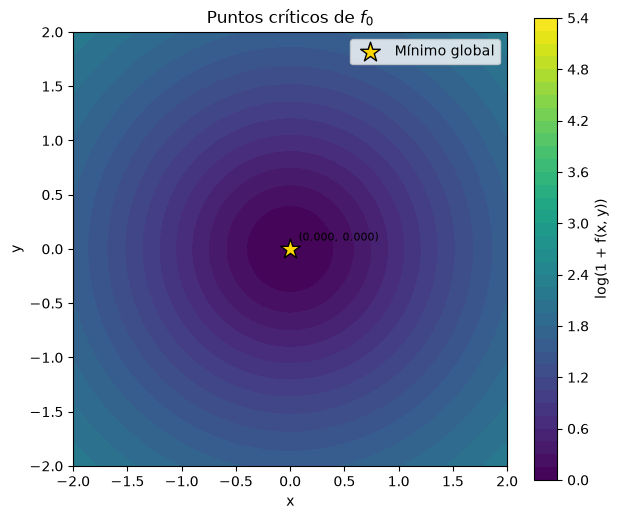

In [18]:
plot_critical_points(
    X,
    Y,
    Z0,
    minimos_globales_f0,
    minimos_locales_f0,
    puntos_silla_f0,
    title=r"Puntos críticos de $f_0$",
    view_limits=(-2.0, 2.0),
)

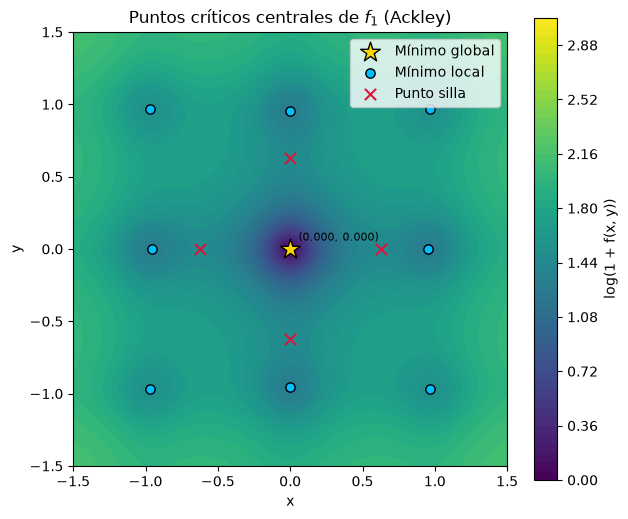

In [28]:
plot_critical_points(
    X,
    Y,
    Z1,
    minimos_globales_f1,
    minimos_locales_f1,
    puntos_silla_f1,
    title=r"Puntos críticos centrales de $f_1$ (Ackley)",
    view_limits=(-1.5, 1.5),
)

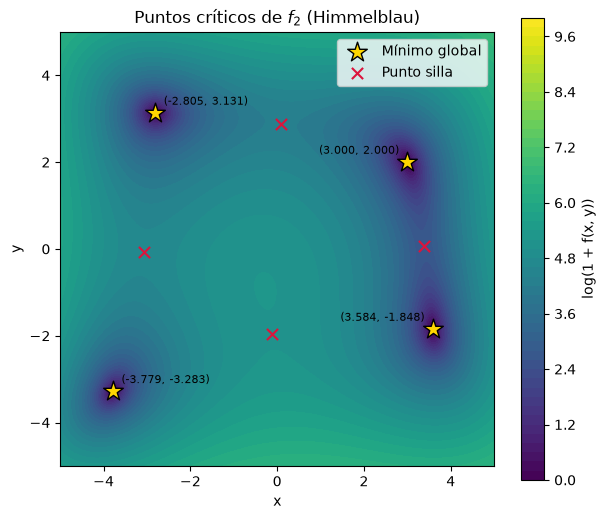

In [20]:
plot_critical_points(
    X,
    Y,
    Z2,
    minimos_globales_f2,
    minimos_locales_f2,
    puntos_silla_f2,
    title=r"Puntos críticos de $f_2$ (Himmelblau)",
    view_limits=(-5.0, 5.0),
)

## Descenso del gradiente

- TODO: Implementar, calibrar, evaluar y documentar el método.


In [21]:
# TODO: Implementación autocontenida del GD para cada función

## RMSprop

- TODO: Implementar, calibrar, evaluar y documentar el método.


In [22]:
# TODO: Implementación autocontenida de RMSprop.


## Enjambre de partículas

- TODO: Implementar, calibrar, evaluar y documentar el método.


In [23]:
# TODO: Implementación autocontenida del enjambre de partículas.


## Calibración de hiperparámetros

- TODO: Registrar la herramienta elegida, espacios de búsqueda y mejores valores.
- TODO: Presentar las curvas de aprendizaje requeridas.


In [24]:
# TODO: Calibración reproducible de los hiperparámetros.


## Pruebas unitarias

Mantener aquí al menos dos pruebas documentadas por cada método. Las pruebas forman parte del notebook autocontenido.


In [25]:
# TODO: Pruebas unitarias documentadas para cada método.


## Evaluación y resultados

- TODO: Ejecutar el protocolo común y resumir las corridas.
- TODO: Conservar tablas, curvas y trayectorias finales.


In [26]:
# TODO: Evaluación comparativa y resultados finales.


## Comparación, conclusiones y referencias

- TODO: Comparar los métodos a partir de resultados reproducibles.
- TODO: Responder las preguntas conceptuales y citar fuentes externas.
- TODO: Registrar limitaciones y conclusiones.
